# Testing

In [1]:
from lapsim.normalisation import TransformNormalisation
from lapsim.evals.evaluate import  evaluate, estimate_lap_time, calculate_optimal_positions, find_apexes
import webdataset as wd

FORESIGHT = 120
SAMPLING = 4
# NORMALISATION_BOUNDS_PATH = "bounds.json"
NORMALISATION_BOUNDS_PATH = "bounds-10.json"

DATESET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-real-00.tar"

bounds = TransformNormalisation.load(NORMALISATION_BOUNDS_PATH)
bounds.transform.method = "flat-window"
bounds.transform.foresight = FORESIGHT
bounds.transform.sampling = SAMPLING


In [2]:
from lapsim.models.lapsim import LapSimModel
import webdataset
from lapsim.preprocessor.encoder import decode
import json
import numpy as np
import mlflow
import torch
import os
import mlflow

model = LapSimModel(
    "ls2.pt",
    bounds
)

os.environ["MLFLOW_TRACKING_URI"] = "http://192.168.0.180:5000"
model.model = mlflow.pytorch.load_model(
    "mlflow-artifacts:/1/models/m-b97f7f4faaac4b7daa80bcc0625b83a6/artifacts", 
    map_location=model.device
)

dataset = webdataset.WebDataset(DATESET)\
    .map(decode)



2026/06/18 22:07:03 WARNING mlflow.pytorch: Stored model version '2.10.0+cu130' does not match installed PyTorch version '2.10.0'
/Users/belle/Developer/MlLapSim/venv/lib/python3.14/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


In [3]:
# Run predictions
requests = list(dataset)
predictions = model.predict(requests)
pairs = list(zip(requests, predictions))

Donea Mx5 Mk3 - US Las Vegas Motor Speedway - Outfield North Road Course                                                                                    


In [4]:


errors = evaluate(pairs)

for key, value in errors.items():
    if "sorted" in key: 
        continue
        
    print(key, value)

laptime/mean 0.11545777
laptime/mean-abs 1.0102487
laptime/rmse 1.4422107
laptime/percentile-25 0.31821442
laptime/percentile-50 0.7185631
laptime/percentile-75 1.3641968
laptime/percentile-95 2.960228
laptime/max 12.996666
laptime-per-kilometer/mean 0.025701212
laptime-per-kilometer/mean-abs 0.35980362
laptime-per-kilometer/rmse 0.7784851
laptime-per-kilometer/percentile-25 0.09335285
laptime-per-kilometer/percentile-50 0.20786688
laptime-per-kilometer/percentile-75 0.3993178
laptime-per-kilometer/percentile-95 1.0409976
laptime-per-kilometer/max 17.686674
position/mean -0.074209735
position/mean-abs 0.6882255
position/rmse 1.2007737
position/percentile-25 0.1141698
position/percentile-50 0.3450779
position/percentile-75 0.84489644
position/percentile-95 2.5647783
position/max 20.724813
position/apex/mean 0.062435076
position/apex/mean-abs 0.31835526
position/apex/rmse 0.8019227
position/apex/percentile-25 0.021695573
position/apex/percentile-50 0.08475834
position/apex/percentile-75 

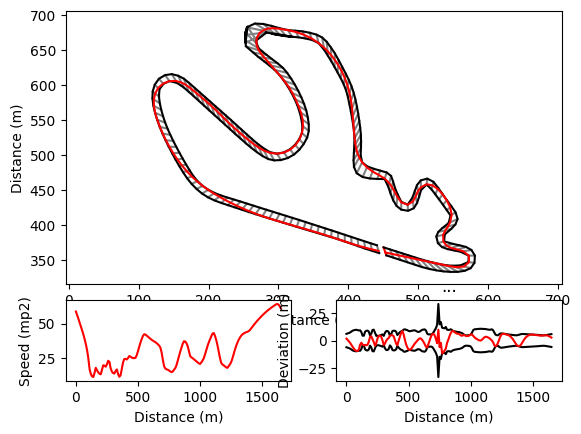

In [25]:
bounds.bounds.max_width

largest = 0, None

for track in dataset:
    track_max_width = np.max(track["widths"])
    if track_max_width > largest[0]:
        largest = track_max_width, track

from toolkit import maths


max(largest[1]["widths"])

from lapsim.render import plot_full, RenderItem

plot_full(
    tracks=[
        RenderItem(
            track=largest[1],
            label="Predicted",
            color="red"
        ),
    ],
    title="..."
)

In [21]:
import lapsim.render

In [23]:
dir(lapsim.render.plot_full)

['List',
 'RenderItem',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'decompress',
 'evaluate',
 'maths',
 'np',
 'plot_full',
 'plot_lateral_deviation',
 'plot_track',
 'plot_velocities',
 'render_item']

In [5]:



# todo check the widths
# todo scan data to make sure no crosses


plot_full(
    tracks=[
        RenderItem(
            track=pairs[0][1],
            label="Predicted",
            color="red"
        ),
    ],
    title="..."
)



NameError: name 'plot_full' is not defined

In [48]:
TRAIN_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-train-{00..04}.tar"
VALIDATION_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-validation-00.tar"
TEST_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-test-00.tar"
REAL_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-real-00.tar"


dataset = webdataset.WebDataset(TRAIN_DATASET)\
    .map(decode)

items = []
for record in dataset:
    items.append((record, np.max(record["widths"])))

# rank items by how bad the widths are
items = sorted(items, key=lambda x: x[1], reverse=True)
items = [x[0] for x in items]


847216896


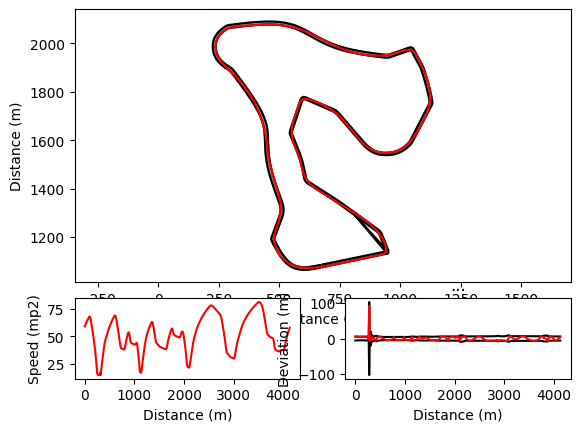

847216896-flipped


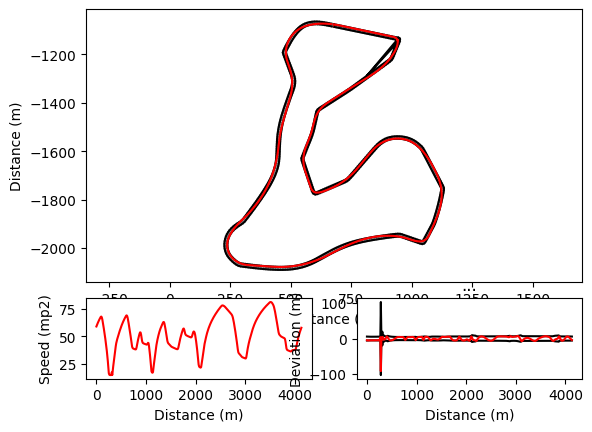

264525932


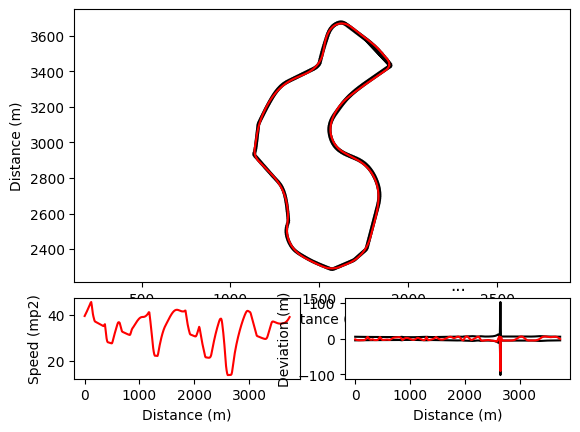

264525932-flipped


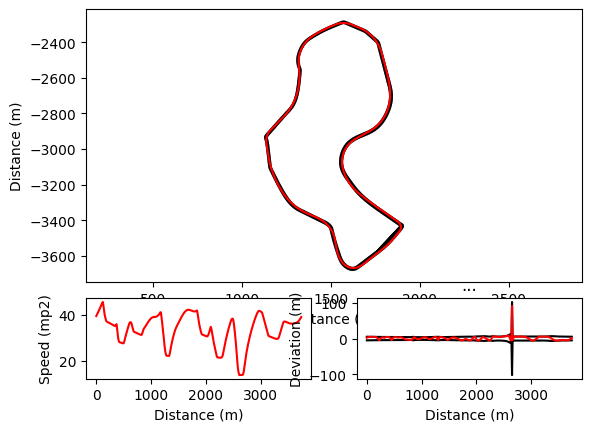

197594281


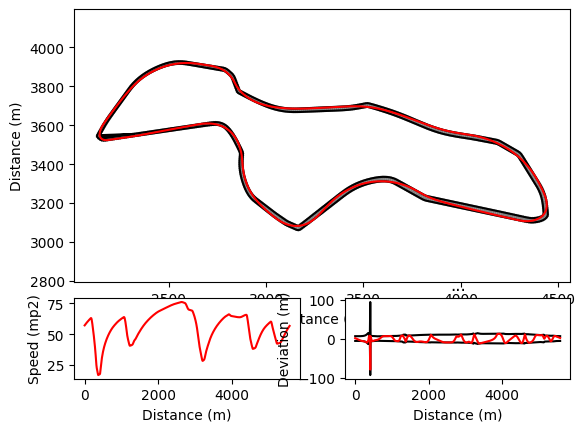

197594281-flipped


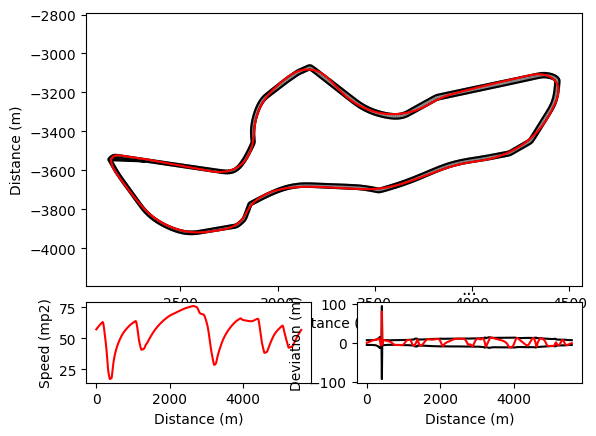

839980525


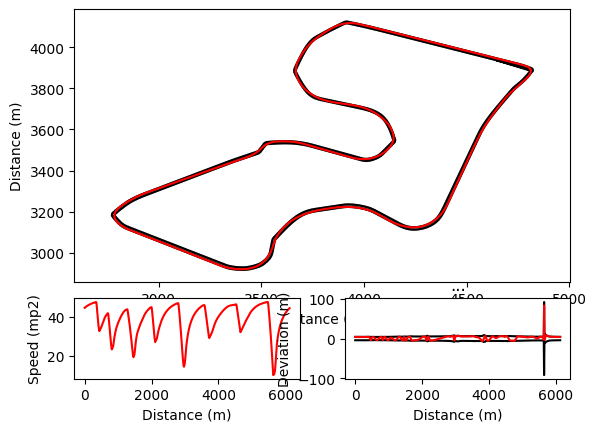

839980525-flipped


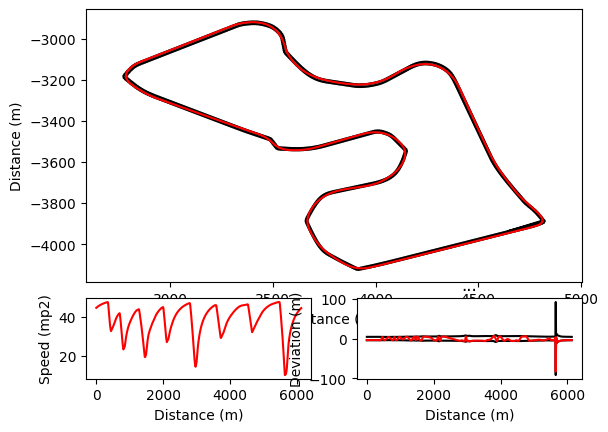

271715194


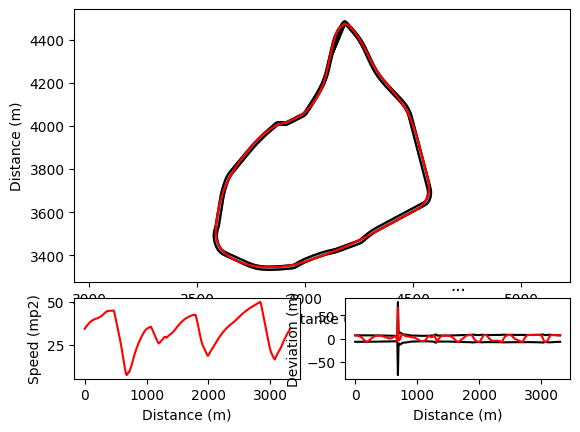

271715194-flipped


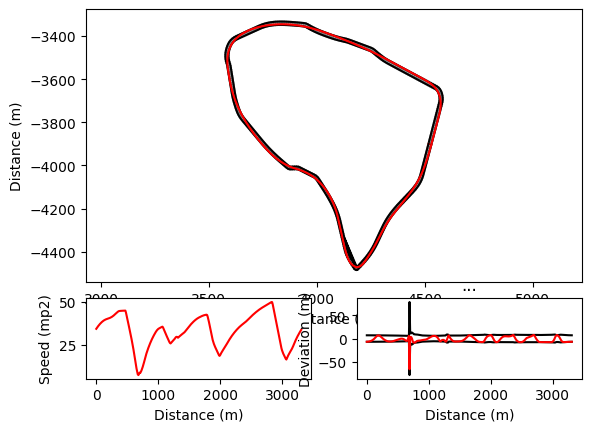

In [50]:
from lapsim.render import RenderItem, plot_full

for i, record in enumerate(items[:10]):
    print(record["id"])
    plot_full(
        tracks=[
            RenderItem(
                track=record,
                label="Predicted",
                color="red"
            ),
        ],
        title="..."
    )


In [ ]:
eval_pairs = [x for x in pairs if x[0]["id"] in best_tracks]

In [ ]:
from lapsim.render import RenderItem, plot_full

for i, (input_record, output_record) in enumerate(eval_pairs):
    print(input_record["id"])
    plot_full(
        tracks=[
            RenderItem(
                track=output_record,
                label="Predicted",
                color="red"
            ),
            RenderItem(
                track=input_record,
                label="Ground Truth",
                color="green"
            ),
        ],
        title="..."
    )


In [ ]:
from lapsim.evals.evaluation import Evaluation
import pandas as pd

# import pandas as pd
# from neural_simulator_toolkit.lapsim.models.evaluation import Evaluation

# filter out none apex errors as they currently result in an issue
evaluatable_comparisons = [x for x in evaluations if x.position.apex_mean is not None]

combined = Evaluation.combine(evaluatable_comparisons)

combined.print_string()

print()


B## Combine Results
This combines results together based on track/vehicle results

In [ ]:
errors_by_track = {}
errors_by_vehicle = {}

for key, value, _, _ in evaluations:
    tokens = key.split(" - ")
    vehicle, track = tokens[0], " - ".join(tokens[1:])
    
    if track not in errors_by_track:
        errors_by_track[track] = []
    if vehicle not in errors_by_vehicle:
        errors_by_vehicle[vehicle] = []

    if value.position.apex_mean is not None:
        errors_by_track[track].append(value)
        errors_by_vehicle[vehicle].append(value)

for key in errors_by_vehicle:
    errors_by_vehicle[key] = Evaluation.combine(errors_by_vehicle[key])
for key in errors_by_track:
    errors_by_track[key] = Evaluation.combine(errors_by_track[key])


In [ ]:
def errors_to_df(errors):
    keys = list(errors)

    return pd.DataFrame({
        "Type": keys,
        "LapTime Error": [errors[x].laptime.abs_error for x in keys],
        "LapTime Percentage": [errors[x].laptime.percentage for x in keys],
        "LapTime Error Per Minute": [errors[x].laptime.error_per_minute for x in keys],

        "Position Error": [errors[x].position.mean_absolute for x in keys],
        "Position ci95": [errors[x].position.ci95 for x in keys],

        "Velocity Error": [errors[x].velocity.mean_absolute for x in keys],
        "Velocity ci95": [errors[x].velocity.ci95 for x in keys]
    })

vehicles_df = errors_to_df(errors_by_vehicle)
track_df = errors_to_df(errors_by_track)


In [ ]:
track_df